In [52]:
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

학습셋 이미지 수: 60000개
테스트셋 이미지 수: 10000개


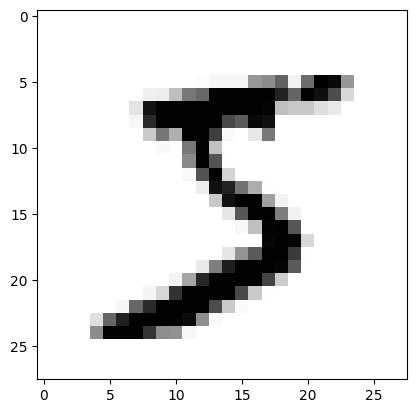

In [29]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("학습셋 이미지 수: %d개" % (X_train.shape[0]))
print("테스트셋 이미지 수: %d개" % (X_test.shape[0]))

plt.imshow(X_train[0],cmap = 'Greys')
plt.show()

In [30]:
for x in X_train[0]:
    for i in x:
        sys.stdout.write("%-3s" % i)
    sys.stdout.write('\n')

X_train = X_train.reshape(X_train.shape[0], 784)
X_train = X_train.astype('float64')
X_train = X_train / 255

X_test = X_test.reshape(X_test.shape[0], 784).astype('float64') / 255

print('class: %d' % (y_train[0]))

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train[0])

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

In [31]:
model = Sequential()
model.add(Dense(512, input_dim = 784, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))
model.summary()
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

modelpath = './MNIST_MLP.keras'
checkpointer = ModelCheckpoint(filepath = modelpath, monitor = 'val_loss', verbose = 1, save_best_only = True)
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 10)

history = model.fit(X_train, y_train, validation_split = 0.25, epochs = 30, batch_size = 200, verbose = 0, callbacks = [early_stopping_callback, checkpointer])

print('\n Test Accuracy: %.4f' % (model.evaluate(X_test, y_test)[1]))

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: val_loss improved from None to 0.19056, saving model to ./MNIST_MLP.keras

Epoch 1: finished saving model to ./MNIST_MLP.keras

Epoch 2: val_loss improved from 0.19056 to 0.13397, saving model to ./MNIST_MLP.keras

Epoch 2: finished saving model to ./MNIST_MLP.keras

Epoch 3: val_loss improved from 0.13397 to 0.12193, saving model to ./MNIST_MLP.keras

Epoch 3: finished saving model to ./MNIST_MLP.keras

Epoch 4: val_loss improved from 0.12193 to 0.10566, saving model to ./MNIST_MLP.keras

Epoch 4: finished saving model to ./MNIST_MLP.keras

Epoch 5: val_loss improved from 0.10566 to 0.09518, saving model to ./MNIST_MLP.keras

Epoch 5: finished saving model to ./MNIST_MLP.keras

Epoch 6: val_loss improved from 0.09518 to 0.09297, saving model to ./MNIST_MLP.keras

Epoch 6: finished saving model to ./MNIST_MLP.keras

Epoch 7: val_loss improved from 0.09297 to 0.08571, saving model to ./MNIST_MLP.keras

Epoch 7: finished saving model to ./MNIST_MLP.keras

Epoch 8: val_loss did 

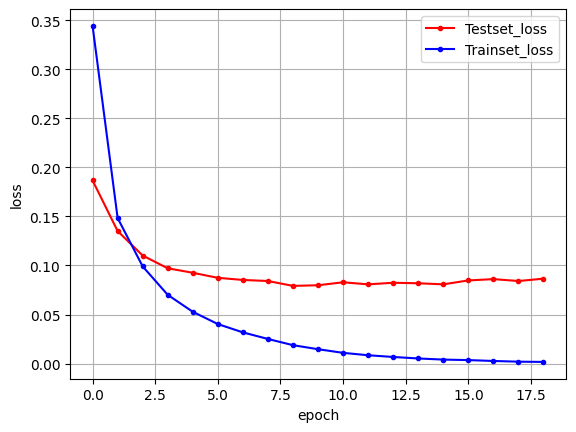

In [ ]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker = '.', c = 'red', label = 'Testset_loss')
plt.plot(x_len, y_loss, marker = '.', c = 'blue', label = 'Trainset_loss')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [32]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [34]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), input_shape = (28, 28, 1), activation = 'relu'))
model.add(Conv2D(64, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

modelpath = './MNIST_MLP.keras'
checkpointer = ModelCheckpoint(filepath = modelpath, monitor = 'val_loss', verbose = 1, save_best_only = True)
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 10)

history = model.fit(X_train, y_train, validation_split = 0.25, epochs = 30, batch_size = 200, verbose = 0, callbacks = [early_stopping_callback, checkpointer])

print('\n Test Accuracy: %.4f' % (model.evaluate(X_test, y_test)[1]))


Epoch 1: val_loss improved from None to 0.08895, saving model to ./MNIST_MLP.keras

Epoch 1: finished saving model to ./MNIST_MLP.keras

Epoch 2: val_loss improved from 0.08895 to 0.05979, saving model to ./MNIST_MLP.keras

Epoch 2: finished saving model to ./MNIST_MLP.keras

Epoch 3: val_loss improved from 0.05979 to 0.04857, saving model to ./MNIST_MLP.keras

Epoch 3: finished saving model to ./MNIST_MLP.keras

Epoch 4: val_loss improved from 0.04857 to 0.04539, saving model to ./MNIST_MLP.keras

Epoch 4: finished saving model to ./MNIST_MLP.keras

Epoch 5: val_loss did not improve from 0.04539

Epoch 6: val_loss improved from 0.04539 to 0.04384, saving model to ./MNIST_MLP.keras

Epoch 6: finished saving model to ./MNIST_MLP.keras

Epoch 7: val_loss did not improve from 0.04384

Epoch 8: val_loss improved from 0.04384 to 0.04234, saving model to ./MNIST_MLP.keras

Epoch 8: finished saving model to ./MNIST_MLP.keras

Epoch 9: val_loss did not improve from 0.04234

Epoch 10: val_loss

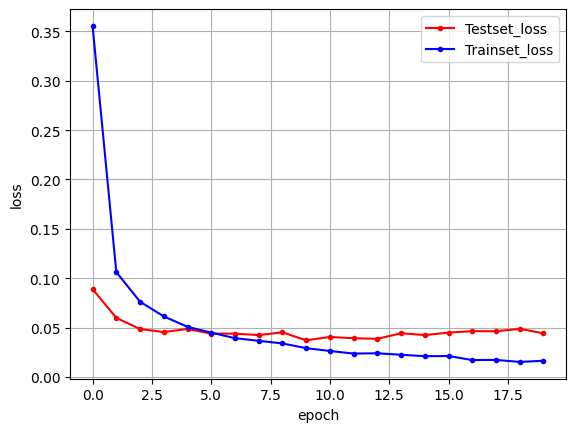

In [35]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker = '.', c = 'red', label = 'Testset_loss')
plt.plot(x_len, y_loss, marker = '.', c = 'blue', label = 'Trainset_loss')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

학습셋 이미지 수: 60000개
테스트셋 이미지 수: 10000개


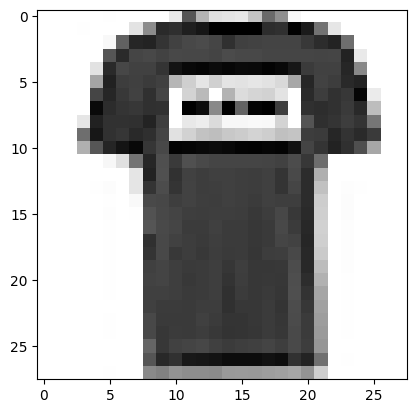

In [97]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("학습셋 이미지 수: %d개" % (X_train.shape[0]))
print("테스트셋 이미지 수: %d개" % (X_test.shape[0]))

plt.imshow(X_train[1],cmap = 'Greys')
plt.show()

In [48]:
for x in X_train[1]:
    for i in x:
        sys.stdout.write("%-3s" % i)
    sys.stdout.write('\n')

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train[1])

0  0  0  0  0  1  0  0  0  0  41 18810354 48 43 87 16813316 0  0  0  0  0  0  0  0  
0  0  0  1  0  0  0  49 13621921622823625525525525521721525423116045 0  0  0  0  0  
0  0  0  0  0  14 1762222242122031981962002152042022012012012092182241640  0  0  0  
0  0  0  0  0  18821920019820219819919920119619819820020020020020120022541 0  0  0  
0  0  0  0  51 2191992032032122382482502452492462472522482352072032032221400  0  0  
0  0  0  0  11622620620420720410175 47 73 48 50 45 51 63 1132222022062202240  0  0  
0  0  0  0  2002222092032152000  70 98 0  10359 68 71 49 0  21920621421025038 0  0  
0  0  0  0  2472182122102152140  2542431392551742512552050  21521721420822095 0  0  
0  0  0  45 2262142142152242050  42 35 60 16 17 12 13 70 0  1892162122062121560  0  
0  0  0  16423521421122021620152 71 89 94 83 78 70 76 92 87 2062072222132192080  0  
0  0  0  1061872232372482111982522502482452482522532502522392012122252151931130  0  
0  0  0  0  0  17 54 15922219320819219720020020020020120319521016

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), input_shape = (28, 28, 1), activation = 'relu'))
model.add(Conv2D(64, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

modelpath = './MNIST_MLP.keras'
checkpointer = ModelCheckpoint(filepath = modelpath, monitor = 'val_loss', verbose = 1, save_best_only = True)
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 10)

history = model.fit(X_train, y_train, validation_split = 0.25, epochs = 30, batch_size = 200, verbose = 0, callbacks = [early_stopping_callback, checkpointer])

print('\n Test Accuracy: %.4f' % (model.evaluate(X_test, y_test)[1]))

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_loss improved from None to 0.35129, saving model to ./MNIST_MLP.keras

Epoch 1: finished saving model to ./MNIST_MLP.keras

Epoch 2: val_loss improved from 0.35129 to 0.30310, saving model to ./MNIST_MLP.keras

Epoch 2: finished saving model to ./MNIST_MLP.keras

Epoch 3: val_loss improved from 0.30310 to 0.27315, saving model to ./MNIST_MLP.keras

Epoch 3: finished saving model to ./MNIST_MLP.keras

Epoch 4: val_loss improved from 0.27315 to 0.24994, saving model to ./MNIST_MLP.keras

Epoch 4: finished saving model to ./MNIST_MLP.keras

Epoch 5: val_loss improved from 0.24994 to 0.24237, saving model to ./MNIST_MLP.keras

Epoch 5: finished saving model to ./MNIST_MLP.keras

Epoch 6: val_loss did not improve from 0.24237

Epoch 7: val_loss improved from 0.24237 to 0.23257, saving model to ./MNIST_MLP.keras

Epoch 7: finished saving model to ./MNIST_MLP.keras

Epoch 8: val_loss improved from 0.23257 to 0.22184, saving model to ./MNIST_MLP.keras

Epoch 8: finished saving mo

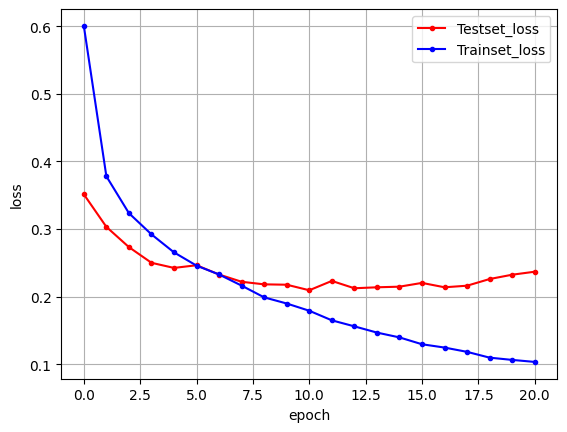

In [42]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker = '.', c = 'red', label = 'Testset_loss')
plt.plot(x_len, y_loss, marker = '.', c = 'blue', label = 'Trainset_loss')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()